This note book prrpares a chatbot with LangChain and LangGraph

In [1]:
#install required packages to the kernel 
%pip install -U langchain langchain-openai langchain-community langchain-chroma langgraph

Note: you may need to restart the kernel to use updated packages.


In [1]:
#define the strucutre of the data that the graph will carry.
#agent/graph state is a dictionary, and it must have a key called message in list format. 
from typing import TypedDict,List
from langchain_core.messages import HumanMessage
#to import List for message we run 

class AgentState(TypedDict):
    messages: List[HumanMessage]

In [2]:
#use openAI API key to use the LLM 
#call the API key as an environment variable
#to manage API key as a local enviornment variable we need OS library, and to load the env variables from .env file we need to install python-dotenv package
%pip install python-dotenv

import os

#load openai key from .env file, first import the library to load env variables
from dotenv import load_dotenv
from pathlib import Path

env_path=Path.cwd() /'.env'#give the .env file path
print("Path to .env file:", env_path)
print("File exists:", env_path.exists())
# Load environment variables from .env file
load_dotenv(env_path,override=True)


#OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
api_key = os.getenv("OPENAI_API_KEY")
print("Loaded:", api_key is not None)
weather_key=os.getenv("OPEN_WEATHER_API_KEY")
print("Loaded:", weather_key is not None)

Note: you may need to restart the kernel to use updated packages.
Path to .env file: c:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain\LangGraph\.env
File exists: True
Loaded: True
Loaded: True


In [3]:
#initialize a language model from the openAI
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.9, openai_api_key=api_key)

c:\Users\shara\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Now we create the graph by adding a node and that node gives the response. Here node is the LLM. so we create the chatbot function for this node as given below
def chatbot(state:AgentState)-> AgentState:
    print("Chatbot function started")
    response=llm.invoke(state["messages"])
    print(f"\n AI:{response.content}")
    return state

In [6]:
#intialize the workfolow and create the simple graph by adding the chatbot node.
from langgraph.graph import StateGraph,START,END
#create the workflow, we gie the strucutre of data we want to keep in this state
workflow=StateGraph(AgentState)
#add hello function to the workflow as a node. here "hellofuction" is the node name . e add the hello function here
workflow.add_node("chatbotFunction",chatbot)
#create the first edge from start to hellow node
workflow.add_edge(START,"chatbotFunction")
#create the last edge from hello to end
workflow.add_edge("chatbotFunction",END)

#complie the graph
app=workflow.compile()

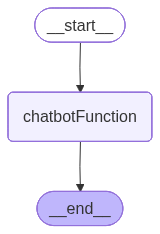

In [7]:
#visualze the create graph
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
#intall the input textbox inside the notebooks. we need this to handle the userinput function in our notbook later when we using the chatbot.
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 5.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------------------------------- ------ 1.8/2.2 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 9.9 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In [16]:
#use the created graph. 
#we give a userinput as the message
import ipywidgets as widgets
from IPython.display import display, clear_output
from langchain_core.messages import HumanMessage

query_box = widgets.Text(
    placeholder="Type your question here",
    description="Query:",
    layout=widgets.Layout(width="80%")
)

ask_button = widgets.Button(description="Ask")
output = widgets.Output()

def ask_chatbot(button):
    with output:
        clear_output()

        user_input = query_box.value

        if user_input.strip() == "":
            print("Please enter a query.")
            return

        result = app.invoke({ "messages": [HumanMessage(content=user_input)]})


ask_button.on_click(ask_chatbot)
display(query_box, ask_button, output)

Text(value='', description='Query:', layout=Layout(width='80%'), placeholder='Type your question here')

Button(description='Ask', style=ButtonStyle())

Output()

Now we are going to maintin a the conversation history through out our chat.
Apart from the HumanMessage we use a AImessage from the langchain for this purpose and then use the union of AI message and the Human message

In [17]:
from typing import TypedDict,List,Union
from langchain_core.messages import HumanMessage, AIMessage
#to import List for message we run 

class ConversationalAgentState(TypedDict):
    messages: List[Union[HumanMessage,AIMessage]]

In [18]:
#initialize a language model from the openAI
from langchain_openai import ChatOpenAI
conversational_llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.9, openai_api_key=api_key)

In [19]:
#here we append  the AI message as well into the message
def conversationalchatbot(state:AgentState)-> AgentState:
    print("Chatbot function started")
    response=conversational_llm.invoke(state["messages"])
    state["messages"].append(AIMessage(content=response.content))
    print(f"\n AI:{response.content}")
    return state

In [21]:
#samewrokflow sturcture
from langgraph.graph import StateGraph,START,END
#create the workflow, we gie the strucutre of data we want to keep in this state
conversational_workflow=StateGraph(AgentState)
#add hello function to the workflow as a node. here "hellofuction" is the node name . e add the hello function here
conversational_workflow.add_node("chatbotFunction",conversationalchatbot)
#create the first edge from start to hellow node
conversational_workflow.add_edge(START,"chatbotFunction")
#create the last edge from hello to end
conversational_workflow.add_edge("chatbotFunction",END)

#complie the graph
conversational_app=conversational_workflow.compile()

In [24]:

query_box = widgets.Text(
    placeholder="Type your question here",
    description="Query:",
    layout=widgets.Layout(width="80%")
)

ask_button = widgets.Button(description="Ask")
output = widgets.Output()
history=[]

def ask_chatbot(button):
    global history
    with output:
        clear_output()

        user_input = query_box.value

        if user_input.strip() == "":
            print("Please enter a query.")
            return

        history.append(HumanMessage(content=user_input))
        result = app.invoke({ "messages": history})
        history=result["messages"]

ask_button.on_click(ask_chatbot)
display(query_box, ask_button, output)

Text(value='', description='Query:', layout=Layout(width='80%'), placeholder='Type your question here')

Button(description='Ask', style=ButtonStyle())

Output()